# <font color='blue'> Polynomial Regression </font>

In [6]:
# import libraries and datasets
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state

df = pd.read_csv("../data/processed/housing_filtered.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## <font color='orange'> 2 Degree Polynomial </font>

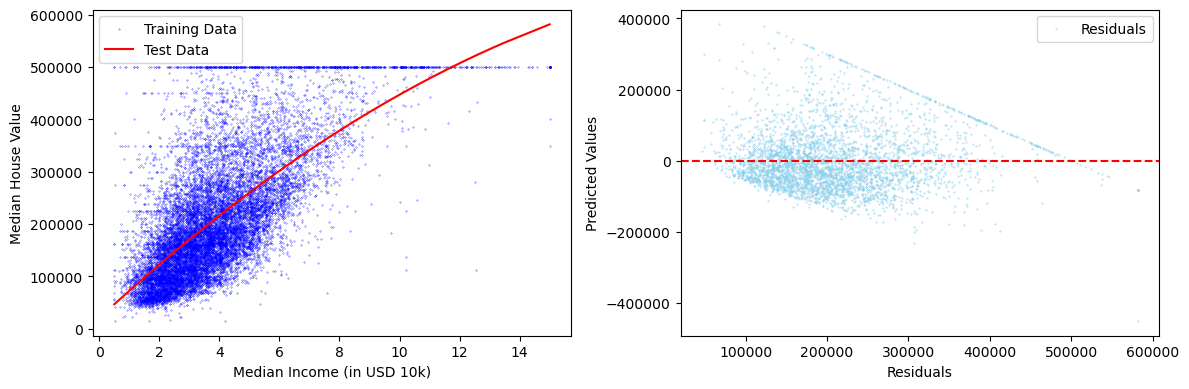

MAE:  62558.30
RMSE: 83328.85
R²:   0.4814


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# define the x and y variables
x = df[['median_income']]
y = df[['median_house_value']]

# split dataset for training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# initialise linear regressor
poly = PolynomialFeatures(degree=2, include_bias=False)

# transform the x-variable
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# train the model using the TRANSFORMED data
poly_reg_model = LinearRegression()
poly_reg_model.fit(x_train_poly, y_train)

# using the transformed variables for prediction
y_test_pred = poly_reg_model.predict(x_test_poly)
y_train_pred = poly_reg_model.predict(x_train_poly)


# plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
axes[0].scatter(x_train, y_train, c='blue', s=0.05, label='Training Data')
idx = x_test['median_income'].argsort()
axes[0].plot(x_test.iloc[idx], y_test_pred[idx], color='red', label='Test Data')
axes[0].set_xlabel('Median Income (in USD 10k)')
axes[0].set_ylabel('Median House Value')
axes[0].legend()

axes[1].scatter(y_test_pred, y_test - y_test_pred , c='skyblue', s=0.1, label='Residuals')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Predicted Values')
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/second_degree_polynomial_regression.pdf")
plt.show()


mae = mean_absolute_error(y_test, y_test_pred)
print(f"MAE:  {mae:.2f}")

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

r2 = r2_score(y_test, y_test_pred)
print(f"R²:   {r2:.4f}")

## <font color='purple'> The polynomial regression performs worse than the linear regression </font>

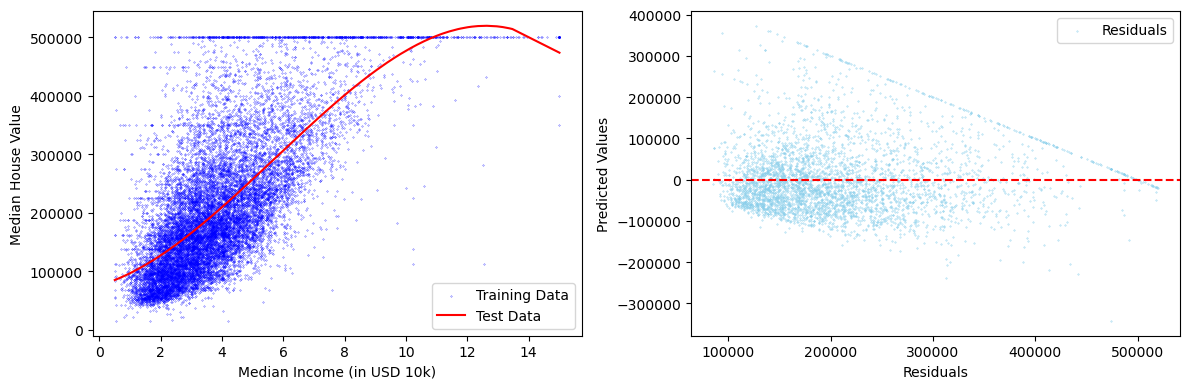

MAE:  61640.86
RMSE: 82548.27
R²:   0.4911


In [13]:
# define the x and y variables
x = df[['median_income']]
y = df[['median_house_value']]

# split dataset for training and testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

# initialise linear regressor
poly = PolynomialFeatures(degree=3, include_bias=False)

# transform the x-variable
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

# train the model using the TRANSFORMED data
poly_reg_model = LinearRegression()
poly_reg_model.fit(x_train_poly, y_train)

# using the transformed variables for prediction
y_test_pred = poly_reg_model.predict(x_test_poly)
y_train_pred = poly_reg_model.predict(x_train_poly)


# plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
axes[0].scatter(x_train, y_train, c='blue', s=0.05, label='Training Data')
idx = x_test['median_income'].argsort()
axes[0].plot(x_test.iloc[idx], y_test_pred[idx], color='red', label='Test Data')
axes[0].set_xlabel('Median Income (in USD 10k)')
axes[0].set_ylabel('Median House Value')
axes[0].legend()

axes[1].scatter(y_test_pred, y_test - y_test_pred , c='skyblue', s=0.1, label='Residuals')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Predicted Values')
axes[1].legend()
plt.tight_layout()
plt.savefig("../figures/third_degree_polynomial_regression.pdf")
plt.show()


mae = mean_absolute_error(y_test, y_test_pred)
print(f"MAE:  {mae:.2f}")

mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")

r2 = r2_score(y_test, y_test_pred)
print(f"R²:   {r2:.4f}")

## <font color='purple'> The degree three polynomial performs a little better than second degree polynomial although not as good as linear regression. </font>